In [41]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
real_folder=r"C:\Users\Venka\facial_verification_project\data\real_vs_fake\real-vs-fake\train\real"
fake_folder=r"C:\Users\Venka\facial_verification_project\data\real_vs_fake\real-vs-fake\train\fake"
files = os.listdir(real_folder)
print(len(files))
print(files[:5])
#file_path =os.path.join(real_folder,files[0])
#Image.open(file_path)

50000
['00000.jpg', '00002.jpg', '00003.jpg', '00006.jpg', '00009.jpg']


['00000.jpg', '00002.jpg', '00003.jpg', '00006.jpg', '00009.jpg']
['001DDU0NI4.jpg', '002KDWZBHU.jpg', '002PMM0QG9.jpg', '002TJAKUYX.jpg', '003IRD4LS5.jpg']


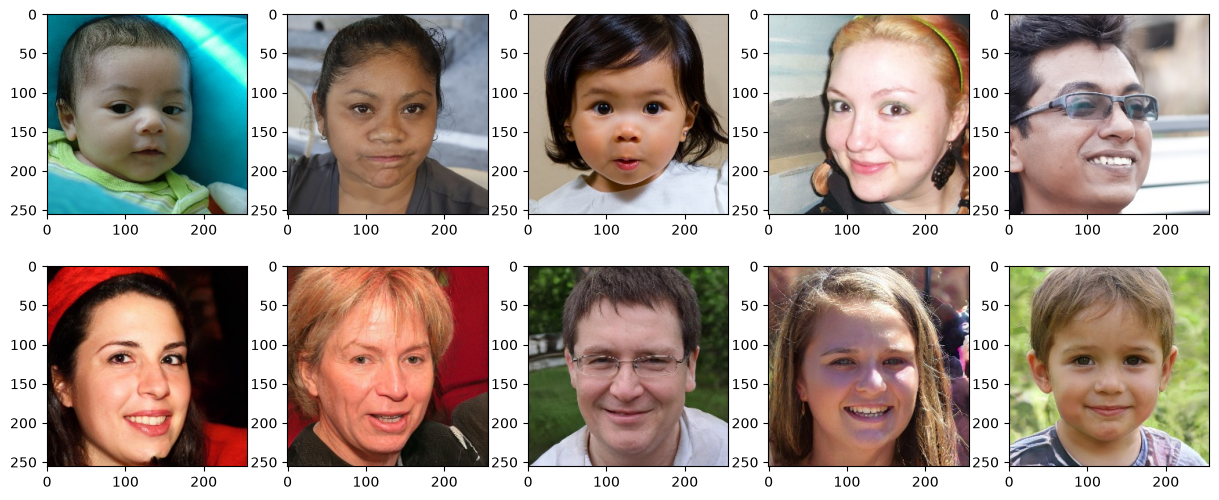

In [15]:
#get details of images
real_file=os.listdir(real_folder)[:5]
fake_file=os.listdir(fake_folder)[:5]
print(real_file)
print(fake_file)

(2, 5)


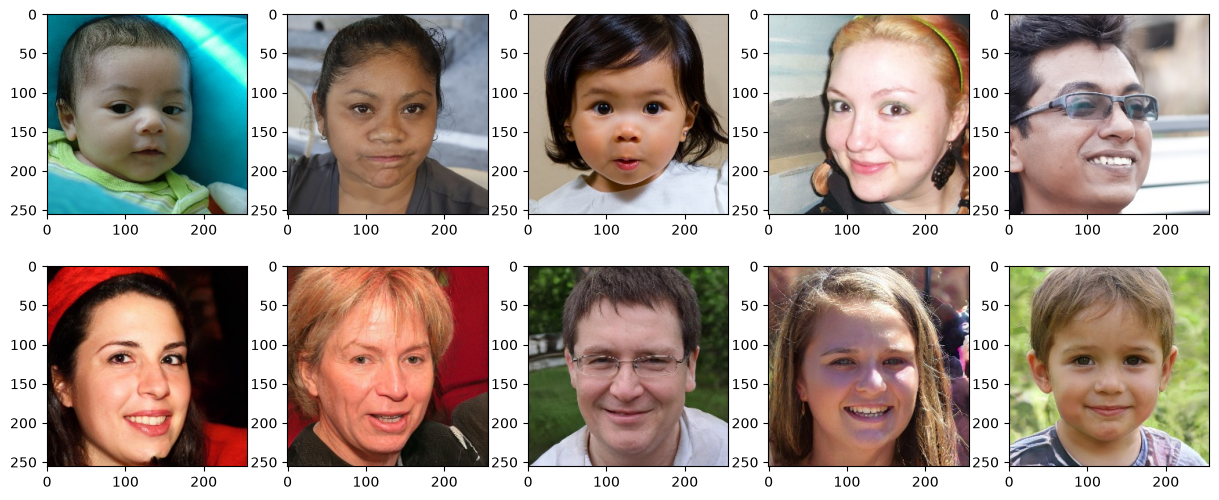

In [16]:
fig,axes=plt.subplots(2,5,figsize=(15,6))
print(axes.shape)
for i,fname in enumerate(real_file):
    image_path=os.path.join(real_folder, fname)
    img=Image.open(image_path)
    axes[0,i].imshow(img)
for i,fname in enumerate(fake_file):
    image_path=os.path.join(fake_folder, fname)
    img=Image.open(image_path)
    axes[1,i].imshow(img)
    

In [27]:
import tensorflow as tf
train_folder=r"C:\Users\Venka\facial_verification_project\data\real_vs_fake\real-vs-fake\train"
train_ds=tf.keras.utils.image_dataset_from_directory(
    train_folder,
    image_size=(224,224),
    batch_size=32
)
valid_folder=r"C:\Users\Venka\facial_verification_project\data\real_vs_fake\real-vs-fake\valid"
val_ds=tf.keras.utils.image_dataset_from_directory(
    valid_folder,
    image_size=(224,224),
    batch_size=32
)

Found 100000 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.


In [32]:
#for research puposes
"""research_model=tf.keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)
research_model.trainable=False
rinputs=tf.keras.Input(shape=(224,224,3))
y=research_model(rinputs, training=False)
y=tf.keras.layers.GlobalAveragePooling2D()(y)
y=tf.keras.layers.Dropout(0.2)(y)
y=tf.keras.layers.Dense(1,activation="sigmoid")(y)
rmodel=tf.keras.Model(rinputs,y)
rmodel.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
rmodel.summary()"""
base_model=tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)
base_model.trainable=False
inputs=tf.keras.Input(shape=(224,224,3))
x=base_model(inputs,training=False)
x=tf.keras.layers.GlobalAveragePooling2D()(x)
x=tf.keras.layers.Dropout(0.2)(x)
x=tf.keras.layers.Dense(1,activation="sigmoid")(x)

model=tf.keras.Model(inputs,x)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [33]:
import time
small_train=train_ds.take(20)
start=time.time()
#rmodel.fit(small_train,epochs=1)
model.fit(small_train,epochs=1)
end=time.time()
print("time for 20 batches:",end-start)

c:\Users\Venka\facial_verification_project\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 558ms/step - accuracy: 0.5391 - loss: 0.7476
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 959ms/step - accuracy: 0.5891 - loss: 0.6635
time for 20 batches: 45.63078284263611


In [ ]:
check_point=tf.keras.callbacks.ModelCheckpoint(
    filepath="best_efficientnet_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)
early_stop=tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

In [36]:


history=model.fit(train_ds,
                  validation_data=val_ds,
                  epochs=50,
                  callbacks=[check_point,early_stop]
                  )

Epoch 1/50


c:\Users\Venka\facial_verification_project\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8072 - loss: 0.4226
Epoch 1: val_accuracy improved from 0.81083 to 0.83605, saving model to best_efficientnet_model.keras

Epoch 1: finished saving model to best_efficientnet_model.keras
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 4722s 2s/step - accuracy: 0.8072 - loss: 0.4226 - val_accuracy: 0.8360 - val_loss: 0.3793
Epoch 2/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8089 - loss: 0.4176
Epoch 2: val_accuracy improved from 0.83605 to 0.84125, saving model to best_efficientnet_model.keras

Epoch 2: finished saving model to best_efficientnet_model.keras
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 5176s 2s/step - accuracy: 0.8089 - loss: 0.4176 - val_accuracy: 0.8413 - val_loss: 0.3710
Epoch 3/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.8102 - loss: 0.4153 
Epoch 3: val_accuracy did not improve from 0.84125
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 64036s 20s/step - accuracy: 0.8102 - loss: 0.4153 - val_accuracy: 0.8391 - val_loss: 0.369

In [38]:
test_folder=r"C:\Users\Venka\facial_verification_project\data\real_vs_fake\real-vs-fake\test"
test_ds=tf.keras.utils.image_dataset_from_directory(
    test_folder,
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)
results=model.evaluate(test_dsepochs=10,
    callback=[early_stop,check_point])
print(results)

Found 20000 files belonging to 2 classes.
625/625 ━━━━━━━━━━━━━━━━━━━━ 491s 784ms/step - accuracy: 0.8437 - loss: 0.3623
[0.3623027801513672, 0.8436999917030334]


In [45]:
from sklearn.metrics import confusion_matrix,classification_report
y_true=np.concatenate([y for x,y in test_ds], axis=0)
y_pred_prob=model.predict(test_ds)
y_pred=(y_pred_prob>0.5).astype(int).flatten()
print(confusion_matrix(y_true,y_pred))
print(classification_report(y_true,y_pred,target_names=["real","fake"]))

625/625 ━━━━━━━━━━━━━━━━━━━━ 505s 803ms/step
[[8453 1547]
 [1579 8421]]
              precision    recall  f1-score   support

        real       0.84      0.85      0.84     10000
        fake       0.84      0.84      0.84     10000

    accuracy                           0.84     20000
   macro avg       0.84      0.84      0.84     20000
weighted avg       0.84      0.84      0.84     20000



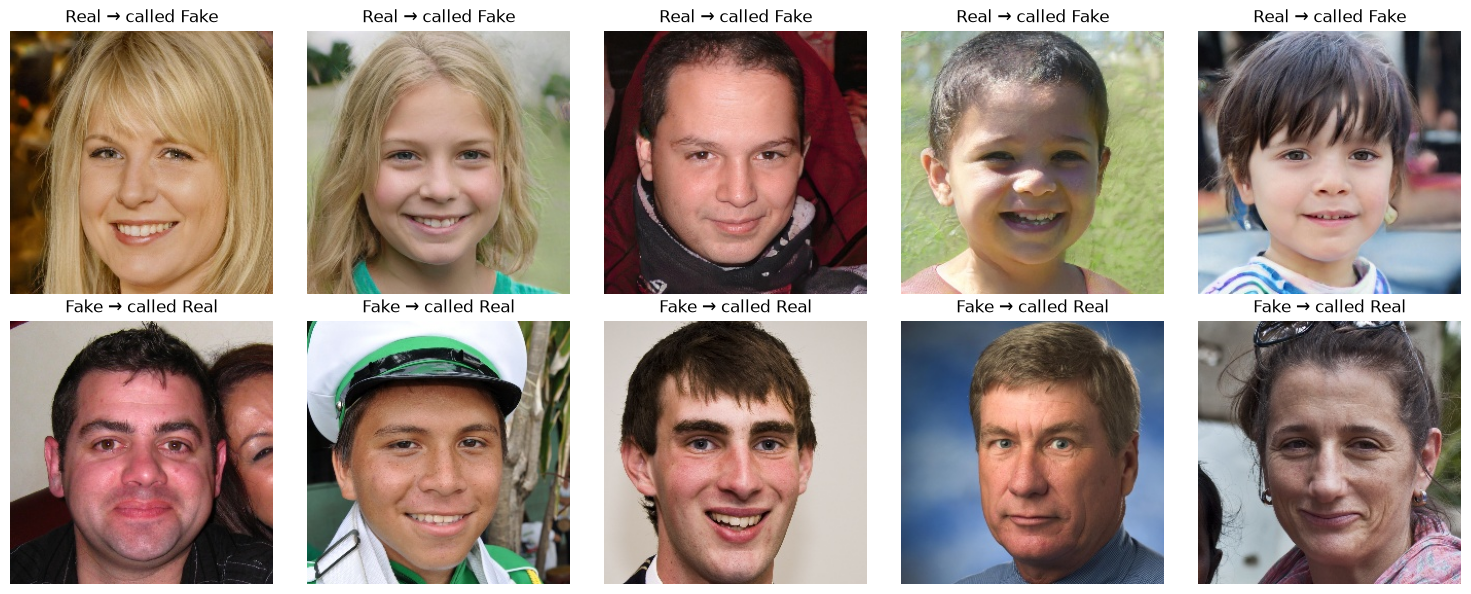

In [51]:
false_positive_index=np.where((y_true==0)&(y_pred==1))[0][:5]
false_negative_index=np.where((y_true==1)&(y_pred==0))[0][:5]
test_filepaths = test_ds.file_paths
false_positive_paths = [test_filepaths[i] for i in false_positive_index]
false_negative_paths = [test_filepaths[i] for i in false_negative_index]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, path in enumerate(false_positive_paths):
    img = Image.open(path)
    axes[0, i].imshow(img)
    axes[0, i].set_title("Real → called Fake")
    axes[0, i].axis("off")

for i, path in enumerate(false_negative_paths):
    img = Image.open(path)
    axes[1, i].imshow(img)
    axes[1, i].set_title("Fake → called Real")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()